In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [62]:
# Probablity mass function

#rolling a single die for 1000 times

l=[]
for i in range(1000):
    l.append(np.random.randint(1,7))
    
len(l)

1000

In [63]:
probability=(pd.Series(l).value_counts()/pd.Series(l).value_counts().sum()).sort_index()# values are not exactly 0.16 as it is a random experiment

<Axes: >

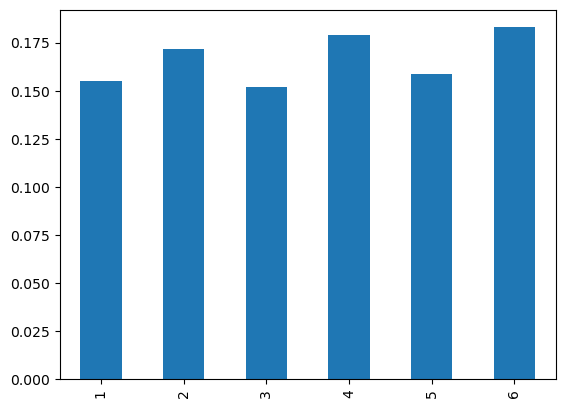

In [64]:
probability.plot(kind='bar')

In [65]:
# fro 2 dies

l=[]
for i in range(1000):
    a=np.random.randint(1,7)
    b=np.random.randint(1,7)
    l.append(a+b)
    
len(l)

1000

In [66]:
probablity=(pd.Series(l).value_counts()/pd.Series(l).value_counts().sum()).sort_index()

<Axes: >

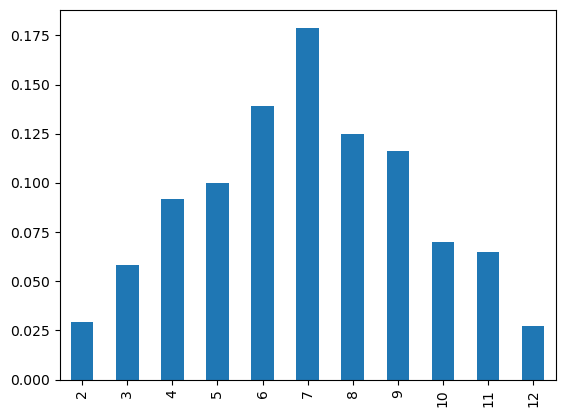

In [67]:
probablity.plot(kind='bar')# it looks like normal distribution and from the pmf we can say the probablity of getting total as 7 is highest in the data

<Axes: >

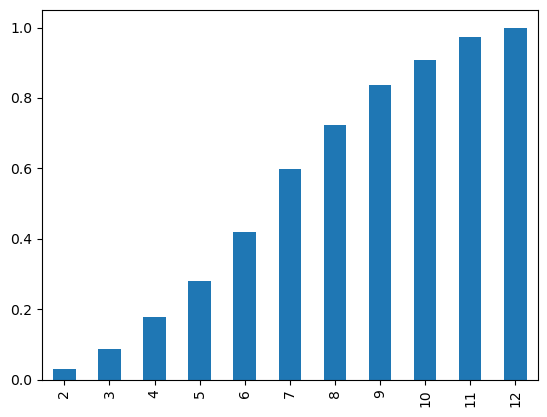

In [68]:
np.cumsum(probablity).plot(kind='bar')# here we can say for bar 7 it gives the probablity of getting 7 or less value after adding 2 dice values like 2,3,4,5,6 upto 7 and rest part tells the probablity of getting more than 7

In [69]:
from numpy.random import normal
sample=normal(loc=50,scale=5,size=1000)#population parameters scale=5 standard deviation and loc=50 mean

(array([  6.,  22.,  71., 159., 209., 202., 170., 111.,  43.,   7.]),
 array([35.29976151, 38.16847189, 41.03718228, 43.90589266, 46.77460305,
        49.64331343, 52.51202382, 55.3807342 , 58.24944459, 61.11815497,
        63.98686536]),
 <BarContainer object of 10 artists>)

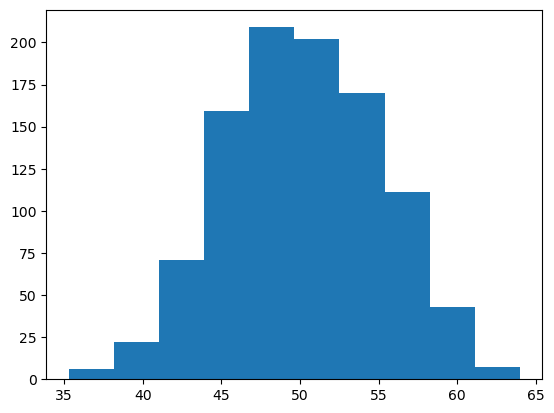

In [70]:
plt.hist(sample,bins=10)# data is kind of following normal distribution

In [71]:
sample_mean=np.mean(sample)
sample_std=np.std(sample)
print(sample_mean,sample_std)

50.14240001938479 4.929935775798155


In [72]:
from scipy.stats import norm
dist=norm(sample_mean,sample_std)

In [73]:
values=np.linspace(np.min(sample),np.max(sample),100)

In [74]:
prob=[dist.pdf(x) for x in values]

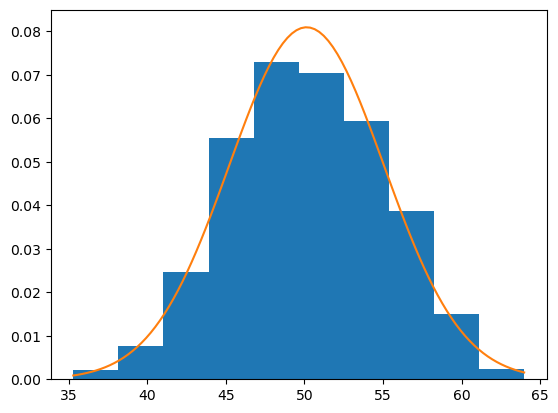

In [75]:
plt.hist(sample,bins=10,density=True)
plt.plot(values,prob)

In [76]:
# we created a sample which is normaly distributed and took it as a population and calculated the mean and standard deviation and passed it to the normal distribution now my pdf function is ready with poulation parameters i created 100 value between the population value range and tried to calculate the probablity of each value in the population using pdf function which is also following normal distribution 
# it is parametric as we are assuming the population is normaly distributed and also taking the mean and standard deviation of the population assuming the sample and population mean is close to each other if we take diffrent mean and std then the pdf function will be completly diffrent
#Since the population parameters are usually unknown, we estimate them using sample mean and sample standard deviation. These estimates are then used to approximate the population distribution and perform statistical analysis.

In [77]:
sample1=normal(loc=20,scale=5,size=300)
sample2=normal(loc=50,scale=5,size=700)
sample=np.hstack((sample1,sample2))

(array([0.00174643, 0.00087322, 0.00174643, 0.00523929, 0.00611251,
        0.00785894, 0.0113518 , 0.01047859, 0.0165911 , 0.01746431,
        0.01397145, 0.02532325, 0.02270361, 0.02357682, 0.02357682,
        0.01833753, 0.01397145, 0.01309823, 0.00873216, 0.00698572,
        0.00523929, 0.00261965, 0.00261965, 0.00174643, 0.00087322,
        0.        , 0.00087322, 0.00087322, 0.00611251, 0.00611251,
        0.01484466, 0.01309823, 0.03056255, 0.03492862, 0.03143576,
        0.04278756, 0.0558858 , 0.05413937, 0.05850544, 0.05239294,
        0.04802686, 0.04278756, 0.03580184, 0.02706968, 0.02008396,
        0.01746431, 0.01047859, 0.00174643, 0.00261965, 0.00174643]),
 array([ 6.20190536,  7.34709793,  8.4922905 ,  9.63748307, 10.78267564,
        11.9278682 , 13.07306077, 14.21825334, 15.36344591, 16.50863848,
        17.65383105, 18.79902362, 19.94421619, 21.08940875, 22.23460132,
        23.37979389, 24.52498646, 25.67017903, 26.8153716 , 27.96056417,
        29.10575674, 30.25

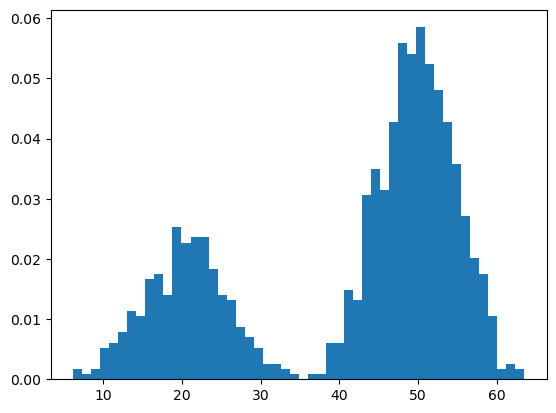

In [78]:
plt.hist(sample,bins=50,density=True)

In [79]:
from sklearn.neighbors import KernelDensity

In [80]:
model=KernelDensity(bandwidth=3,kernel='gaussian')


In [81]:
sample=sample.reshape((len(sample),1))
model.fit(sample)

,bandwidth,3
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [82]:
values=np.linspace(np.min(sample),np.max(sample),100)
prob=model.score_samples(values.reshape((len(values),1)))
prob=np.exp(prob)

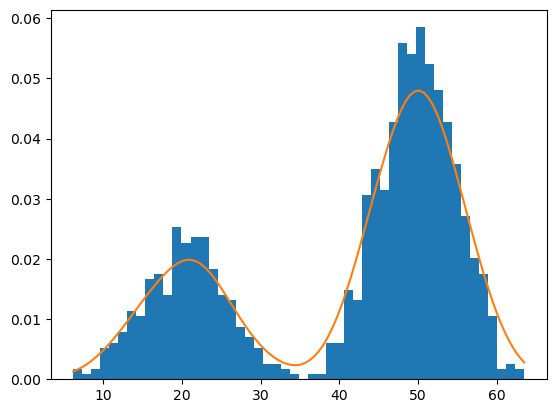

In [83]:
plt.hist(sample,bins=50,density=True)
plt.plot(values,prob)

In [87]:
import seaborn as sns
df=sns.load_dataset('iris')
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

<Axes: xlabel='sepal_width', ylabel='Density'>

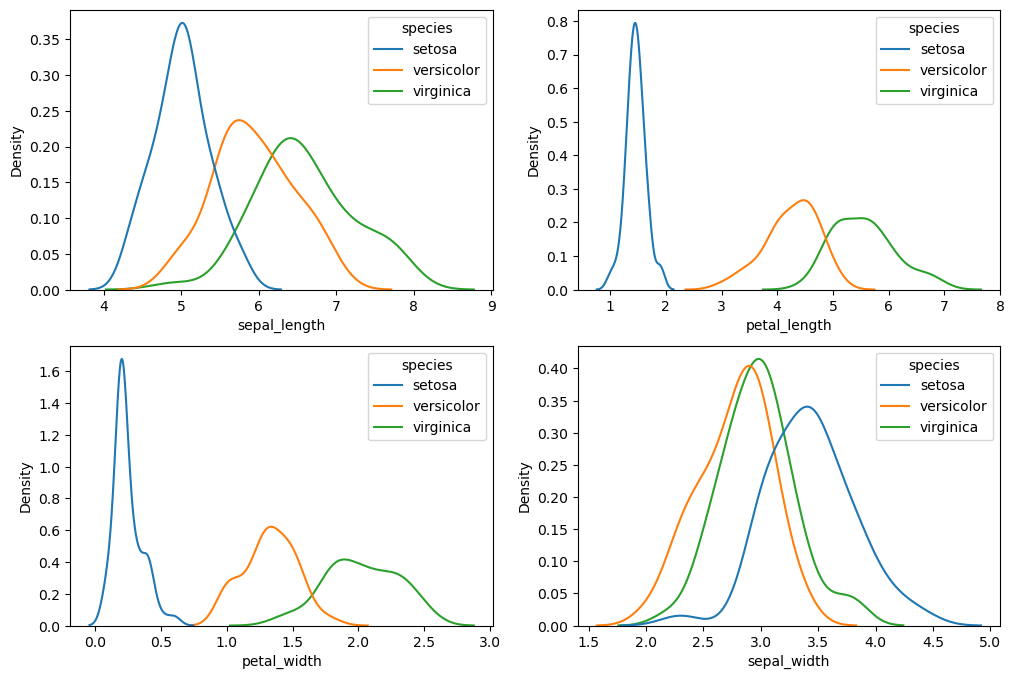

In [ ]:
    # so we ploted kde with the datapoints we have and we can see that petal_length and petal_width are more spread out than sepal_length and sepal_width which means this 2 feature will help us to distinguish between species more than sepal_length and sepal_width from our eye view we can say if petal_width between 0.0 to 0.6 then it is setosa if petal_width between 0.6 to 1.5 then it is versicolor(probably as the density of versicolor is more) if petal_width between 1.8 to 3 then it is virginica(most cases)

    fig, axes = plt.subplots(2, 2, figsize=(12,8))
    sns.kdeplot(data=df,x='sepal_length',hue='species',ax=axes[0,0])
    sns.kdeplot(data=df,x='petal_length',hue='species',ax=axes[0,1])
    sns.kdeplot(data=df,x='petal_width',hue='species',ax=axes[1,0])     
    sns.kdeplot(data=df,x='sepal_width',hue='species',ax=axes[1,1])
    

<Axes: xlabel='petal_width', ylabel='Density'>

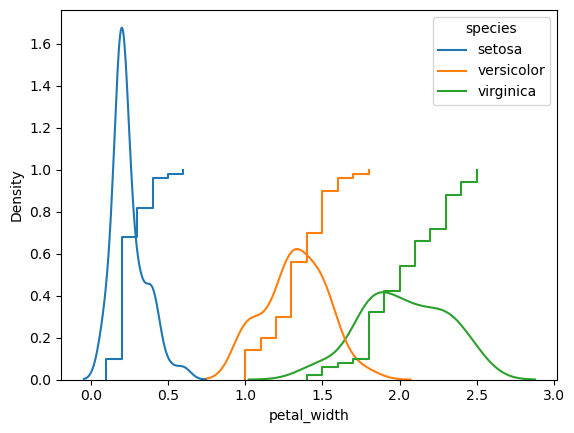

In [ ]:
# in cdf also petal_width is a good feature in species distinguishing
sns.kdeplot(data=df,x='petal_width',hue='species')
sns.ecdfplot(data=df,x='petal_width',hue='species')


In [97]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

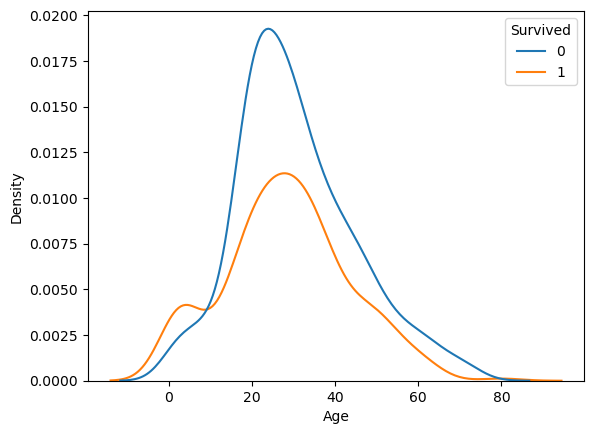

In [ ]:
# here we clearly saw the age between 20 to 40 are more likely to survive as density is more (probablity of getting survived is more)
sns.kdeplot(data=titanic,x='Age',hue='Survived')


<Axes: xlabel='Age', ylabel='Density'>

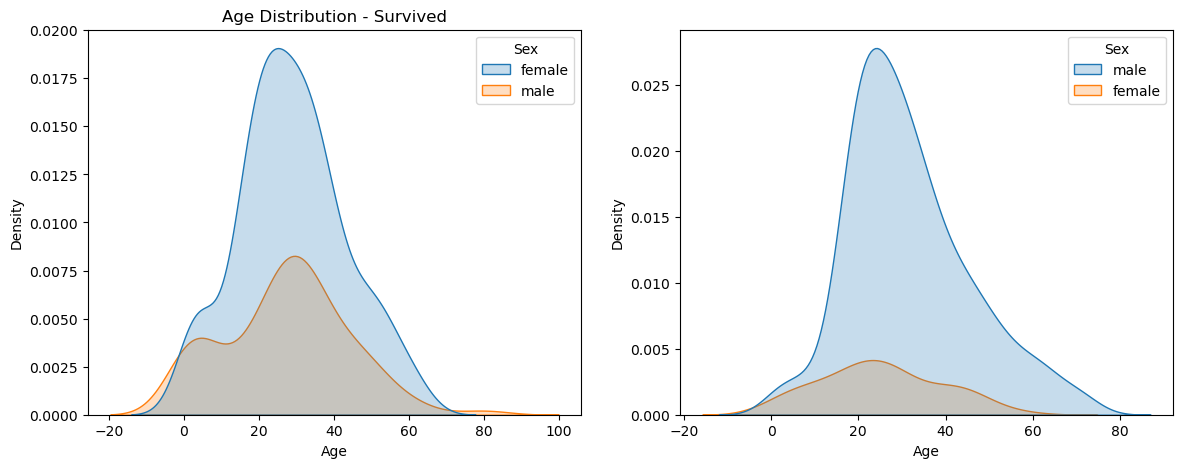

In [ ]:
# we can also see the age between 20 to 40 are more likely to survive as density is more (probablity of getting survived is more) irrespectively of gender
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Survived
sns.kdeplot(data=titanic[titanic['Survived']==1],x='Age',hue='Sex',fill=True,ax=axes[0])

axes[0].set_title('Age Distribution - Survived')

# Not survived
sns.kdeplot(data=titanic[titanic['Survived']==0],x='Age',hue='Sex',fill=True,ax=axes[1])

<Axes: xlabel='Age', ylabel='Density'>

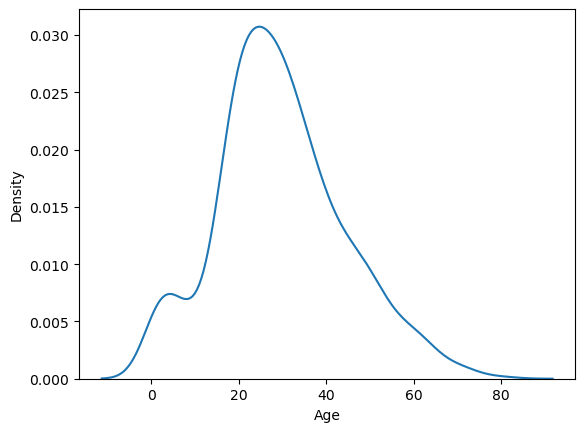

In [ ]:
# from visual we can say age is normally distributed
sns.kdeplot(data=titanic['Age'])

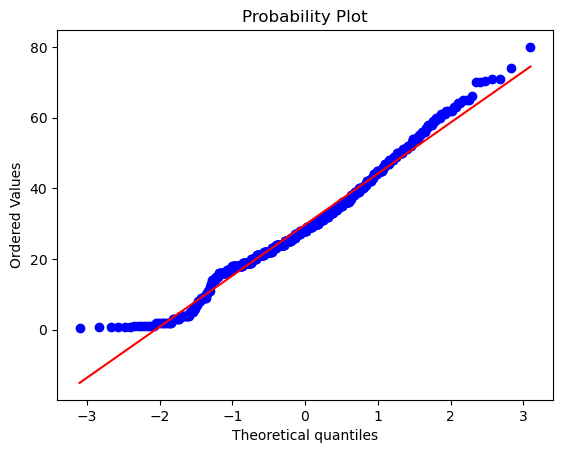

In [110]:
# using QQ plot we can see the data points are nearly forllowing the red line which is theoritical normal distribution line so we can say age is normally distributed
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(titanic['Age'].dropna(), dist='norm', plot=plt)
plt.show()


In [ ]:
# statistical test for small dataset => shapiro test(if p greater than alpha normality is true)
# for large dataset => ks test or normalitytest
from scipy.stats import shapiro
stat, p = shapiro(titanic['Age'].dropna())
print("P-value:", p)
alpha = 0.05
if p > alpha:
    print("Data follows a normal distribution")
else:
    print("Data does not follow a normal distribution")
# it does not mean data is not normally distributed we did not find enough evidence as shapiro test p value is effcted by lower datapoints as we can see in the QQ plot


P-value: 7.337348958673594e-08
Data does not follow a normal distribution


In [116]:
titanic.shape

(891, 12)

In [115]:
from scipy.stats import normaltest

stat, p = normaltest(titanic['Age'].dropna())
print(p)

0.00011709599657350757


In [119]:
print(titanic['Age'].skew())

0.38910778230082704


In [ ]:
#Statistical tests rejected the null hypothesis of normality (p < 0.05), indicating significant deviations from a perfect normal distribution. However, skewness (0.38) and visual inspections through KDE and Q-Q plots suggest the feature is approximately normal, and the low p-values may be due to the sensitivity of normality tests to small deviations in large datasets.
# so to prove that my assumtion about tail event is creating p value to be small i will check kurtosis (tailed heaviness) (≈0→ normal-like tails >0→ heavy tails <0→ lighter tails)
#check outliers using boxplot and IQR 
# create against generated normal distribution using sample data mean and std(parametric kde)
# checking for multimodal data

In [ ]:
# 0.178 
print(titanic['Age'].kurt())

0.17827415364210353


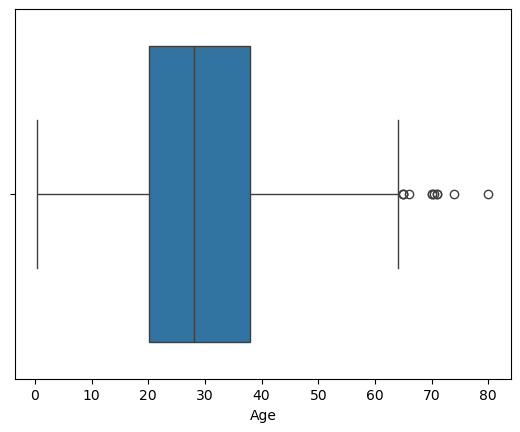

In [ ]:
# outliers are present
sns.boxplot(x=titanic['Age'])
plt.show()

In [ ]:
# so there are 11 outliers
Q1 = titanic['Age'].quantile(.25)
Q3 = titanic['Age'].quantile(.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = titanic[(titanic['Age'] < lower) |(titanic['Age'] > upper)]
print(len(outliers))

11


In [127]:
import numpy as np
from scipy.stats import shapiro

mu = titanic['Age'].mean()
sigma = titanic['Age'].std()

normal_sample = np.random.normal(
    mu,
    sigma,
    titanic['Age'].shape[0]
)

print(shapiro(normal_sample))
print(shapiro(titanic['Age'].dropna()))

ShapiroResult(statistic=np.float64(0.9992394686655375), pvalue=np.float64(0.9807604939567555))
ShapiroResult(statistic=np.float64(0.9814577414504954), pvalue=np.float64(7.337348958673594e-08))


<Axes: xlabel='Age', ylabel='Count'>

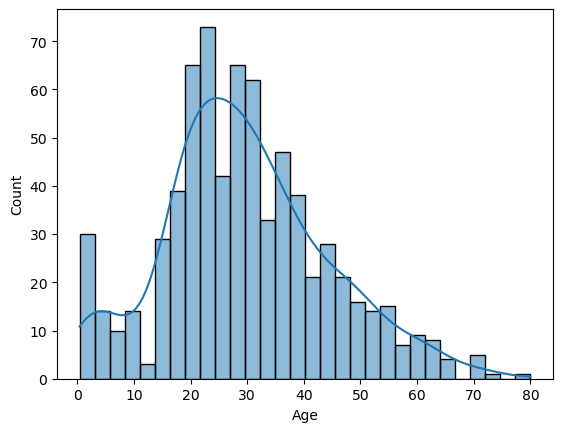

In [129]:
sns.histplot(data=titanic, x='Age', kde=True, bins=30)

<Axes: xlabel='Age', ylabel='Count'>

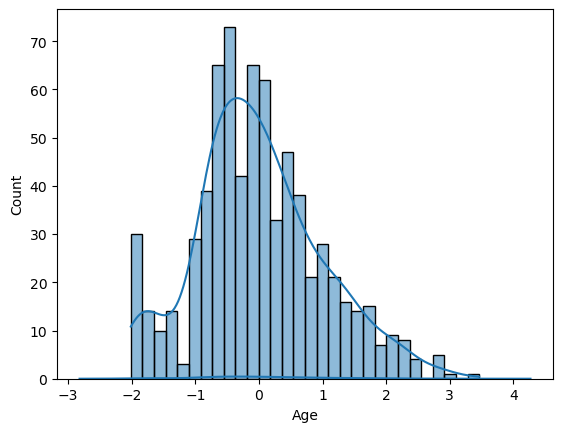

In [132]:
# standard normal distribution(now we have mean 0 and std 1) and we can have z score to find diffrent probabilities
x=(titanic['Age']-titanic['Age'].mean())/titanic['Age'].std()
sns.histplot(data=x, kde=True, bins=30)
sns.kdeplot(data=x)

In [ ]:
#using empirical rule of normal distribution we can check outliers
#assuming the values outside 3 std are outliers

print(titanic['Age'].mean() - 3*titanic['Age'].std())
print(titanic['Age'].mean() + 3*titanic['Age'].std())
# getting the outlier values
titanic[(titanic['Age'] < (titanic['Age'].mean() - 3*titanic['Age'].std())) |(titanic['Age'] > (titanic['Age'].mean() + 3*titanic['Age'].std()))]

-13.88037434994331
73.27860964406095


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S
